# Spectral convolutions on the sphere

This guide explains the **spectral convolution** layer
{class}`~torch_harmonics.SpectralConvS2`.  Unlike the DISCO convolution
(which operates in the spatial domain with compact-support kernels), the
spectral convolution works entirely in the spherical harmonic domain,
making it naturally **isotropic** (azimuthally symmetric) and **global**
in receptive field.

## 1. Convolution via the spectral theorem

On the sphere, convolution with an isotropic (axisymmetric) kernel is
diagonal in the spherical harmonic basis.  This is the spherical analogue
of the classical convolution theorem on $\mathbb{R}^n$: convolution in
the spatial domain corresponds to pointwise multiplication in the spectral
domain.

Given a multi-channel input $u^{c_i}(\theta, \lambda)$, the spectral
convolution computes output channels $v^{c_o}(\theta, \lambda)$ in three
steps:

1. **Forward SHT** — transform each input channel to spectral space:

$$
\hat{u}_l^{m,\,c_i} = \text{SHT}\!\left[\, u^{c_i}(\theta, \lambda) \,\right]
$$

2. **Spectral contraction** — mix channels with learnable weights
   $K_l^{c_o,\,c_i}$ that depend only on degree $l$ (not order $m$):

$$
\hat{v}_l^{m,\,c_o}
    = \sum_{c_i} K_l^{c_o,\,c_i}\; \hat{u}_l^{m,\,c_i}
$$

3. **Inverse SHT** — transform back to the spatial domain:

$$
v^{c_o}(\theta, \lambda)
    = \text{ISHT}\!\left[\, \hat{v}_l^{m,\,c_o} \,\right]
$$

Because the weights depend only on degree $l$ and not on order $m$, this
corresponds to an **isotropic** convolution kernel on the sphere — the
filter response is the same in every direction.

## 2. Spectral vs. spatial convolution

| | Spectral (`SpectralConvS2`) | Spatial (`DiscreteContinuousConvS2`) |
|---|---|---|
| **Domain** | Spherical harmonic (frequency) | Spatial (grid points) |
| **Kernel symmetry** | Isotropic (axisymmetric) | Anisotropic (arbitrary azimuthal dependence) |
| **Receptive field** | Global (all degrees up to $l_{\max}$) | Local (compact support within $\theta_{\text{cutoff}}$) |
| **Cost** | $\mathcal{O}(N \log N)$ (FFT) + $\mathcal{O}(N l_{\max})$ (Legendre) | $\mathcal{O}(kN)$ (sparse, $k$ = neighbors) |
| **Parameters per channel pair** | $l_{\max}$ complex weights | $K$ real weights (basis functions) |
| **Resolution agnostic** | Yes (truncate or zero-pad spectrum) | Yes (re-evaluate $\Psi$ on new grid) |

The spectral convolution is a natural choice when the filter should be
rotationally symmetric (e.g. diffusion, smoothing, spectral filtering).
When the filter needs azimuthal structure (e.g. edge detection, directional
features), the DISCO convolution is more expressive.

## 3. Spectral bias

When `bias=True`, a learnable spectral bias $b_l^{m,\,c_i}$ is added to
the SHT coefficients **before** the channel contraction.  The bias is
modulated by the spatial integral (zeroth moment) of each input channel:

$$
I^{c_i} = \int_0^{2\pi}\!\int_0^{\pi}
    u^{c_i}(\theta,\lambda)\,\sin\theta\;d\theta\;d\lambda
$$

$$
\hat{u}_l^{m,\,c_i} \;\leftarrow\;
    \hat{u}_l^{m,\,c_i} + I^{c_i}\, b_l^{m,\,c_i}
$$

This couples the global mean of each input channel into all spectral
modes, allowing the layer to learn a spectral response that depends on
the overall signal level.

## 4. Example: spectral convolution on Mars elevation

Let's apply a spectral convolution to the Mars MOLA elevation map and
inspect the output.  Because the convolution is isotropic, each output
channel is a rotationally symmetric filtering of the input — similar to
applying a radial low-pass or band-pass filter.

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import torch_harmonics as th
from torch_harmonics.plotting import plot_sphere
from torch_harmonics.utils import load_mola_elevation

nlat, nlon = 128, 256
signal = load_mola_elevation(nlat, nlon).unsqueeze(0).unsqueeze(0)

In [2]:
in_channels, out_channels = 1, 8

torch.manual_seed(333)

spec_conv = th.SpectralConvS2(
    in_shape=(nlat, nlon),
    out_shape=(nlat, nlon),
    in_channels=in_channels,
    out_channels=out_channels,
)

y = spec_conv(signal)

print(f"Input shape:  {signal.shape}")
print(f"Output shape: {y.shape}")
print(f"Spectral weights shape: {spec_conv.weight.shape}")
print("  (num_groups, in_channels/groups, out_channels/groups, lmax)")
print(f"lmax = {spec_conv.lmax}")

/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/torch_harmonics/truncation.py:168: UserWarning: Default SHT truncation changed in v0.9.0: equiangular/equiangular-trapezoidal grids now truncate to (nlat+1)//2. Specify lmax explicitly to override.
  lmax = lmax or _truncate_lmax(nlat, grid)


Input shape:  torch.Size([1, 1, 128, 256])
Output shape: torch.Size([1, 8, 128, 256])
Spectral weights shape: torch.Size([1, 1, 8, 64])
  (num_groups, in_channels/groups, out_channels/groups, lmax)
lmax = 64


/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/torch/_inductor/lowering.py:2633: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


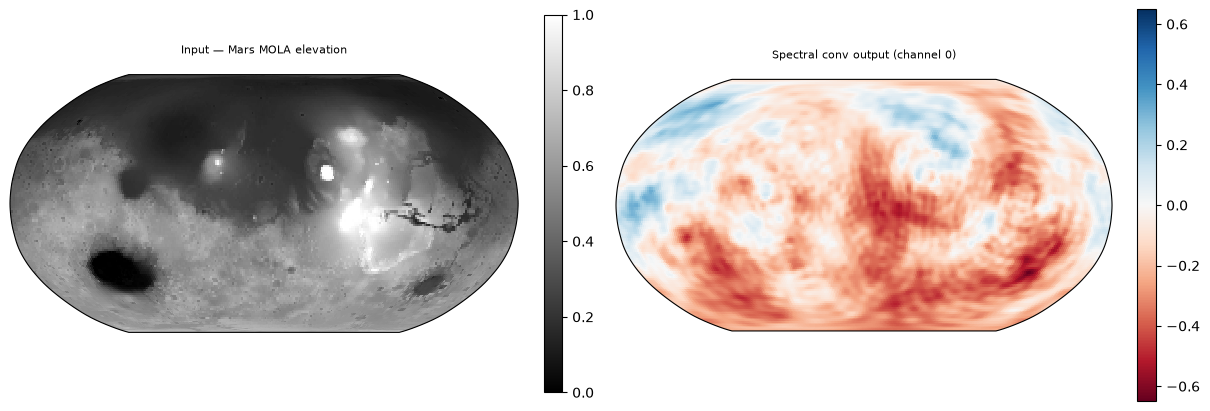

In [3]:
fig = plt.figure(figsize=(12, 4), layout="constrained")
subfigs = fig.subfigures(1, 2)

plot_sphere(signal[0, 0].detach(), fig=subfigs[0], cmap="gray",
            title="Input — Mars MOLA elevation", colorbar=True)

vmax = y[0, 0].abs().max().item()
plot_sphere(y[0, 0].detach(), fig=subfigs[1], cmap="RdBu",
            title="Spectral conv output (channel 0)", colorbar=True,
            vmin=-vmax, vmax=vmax)

plt.show()

## 5. Visualising the spectral weights

Each output channel has a weight vector of length $l_{\max}$ that
controls how strongly each spherical harmonic degree contributes.  Let's
plot the magnitude of the spectral weights for all output channels.

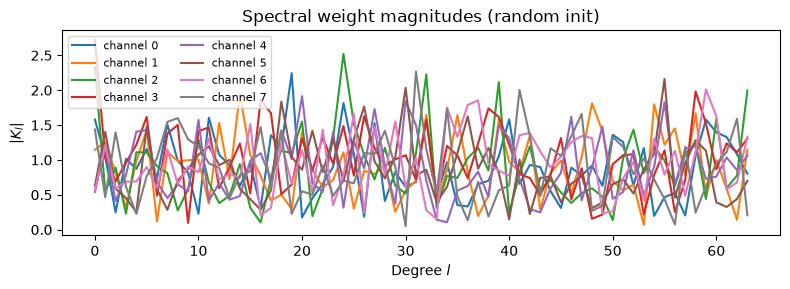

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))

# weight shape: (num_groups, in_ch/groups, out_ch/groups, lmax)
w = spec_conv.weight.detach()
for c in range(out_channels):
    ax.plot(w[0, 0, c].abs().numpy(), label=f"channel {c}")

ax.set_xlabel("Degree $l$")
ax.set_ylabel("$|K_l|$")
ax.set_title("Spectral weight magnitudes (random init)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 6. Grouped spectral convolution

Like grouped convolutions in CNNs, setting `num_groups > 1` partitions
the input and output channels into independent groups.  Each group has
its own spectral weights, reducing the parameter count from
$l_{\max} \times C_{\text{in}} \times C_{\text{out}}$ to
$l_{\max} \times C_{\text{in}} \times C_{\text{out}} / G$ where $G$ is
the number of groups.

In [5]:
in_ch, out_ch = 16, 32

for ng in [1, 4, 16]:
    torch.manual_seed(333)
    sc = th.SpectralConvS2(
        in_shape=(nlat, nlon),
        out_shape=(nlat, nlon),
        in_channels=in_ch,
        out_channels=out_ch,
        num_groups=ng,
    )
    nparams = sum(p.numel() for p in sc.parameters())
    print(f"num_groups={ng:2d}: weight shape {tuple(sc.weight.shape)}, "
          f"total params = {nparams:,}")

num_groups= 1: weight shape (1, 16, 32, 64), total params = 32,768
num_groups= 4: weight shape (4, 4, 8, 64), total params = 8,192
num_groups=16: weight shape (16, 1, 2, 64), total params = 2,048


/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/torch_harmonics/truncation.py:168: UserWarning: Default SHT truncation changed in v0.9.0: equiangular/equiangular-trapezoidal grids now truncate to (nlat+1)//2. Specify lmax explicitly to override.
  lmax = lmax or _truncate_lmax(nlat, grid)


## 7. Resolution transfer

Because the learnable weights live in spectral space, the same weights
can be applied on a different grid resolution — just change `in_shape`
and `out_shape`.  If the new grid has a lower resolution, the spectrum is
truncated to the smaller $l_{\max}$; if higher, the extra modes are
simply absent from the weight tensor (equivalent to zero-padding in
frequency).

In [6]:
for res in [(64, 128), (128, 256), (256, 512)]:
    torch.manual_seed(333)
    sc = th.SpectralConvS2(
        in_shape=res,
        out_shape=res,
        in_channels=1,
        out_channels=8,
    )
    print(f"Grid {res[0]:3d}×{res[1]:3d}: lmax = {sc.lmax}, "
          f"weight shape {tuple(sc.weight.shape)}")

Grid  64×128: lmax = 32, weight shape (1, 1, 8, 32)
Grid 128×256: lmax = 64, weight shape (1, 1, 8, 64)
Grid 256×512: lmax = 128, weight shape (1, 1, 8, 128)


## 8. Up- and downsampling

The input and output grids do not need to match.  Setting a coarser
`out_shape` naturally downsamples through spectral truncation, while a
finer `out_shape` upsamples by synthesising back onto a denser grid.

In [7]:
torch.manual_seed(333)

# downsample: 128x256 -> 64x128
spec_down = th.SpectralConvS2(
    in_shape=(128, 256),
    out_shape=(64, 128),
    in_channels=1,
    out_channels=1,
)

# upsample: 64x128 -> 128x256
spec_up = th.SpectralConvS2(
    in_shape=(64, 128),
    out_shape=(128, 256),
    in_channels=1,
    out_channels=1,
)

y_down = spec_down(signal)
y_up = spec_up(F.interpolate(signal, size=(64, 128), mode="bilinear", align_corners=False))

print(f"Input:       {signal.shape}")
print(f"Downsampled: {y_down.shape}")
print(f"Upsampled:   {y_up.shape}")

Input:       torch.Size([1, 1, 128, 256])
Downsampled: torch.Size([1, 1, 64, 128])
Upsampled:   torch.Size([1, 1, 128, 256])


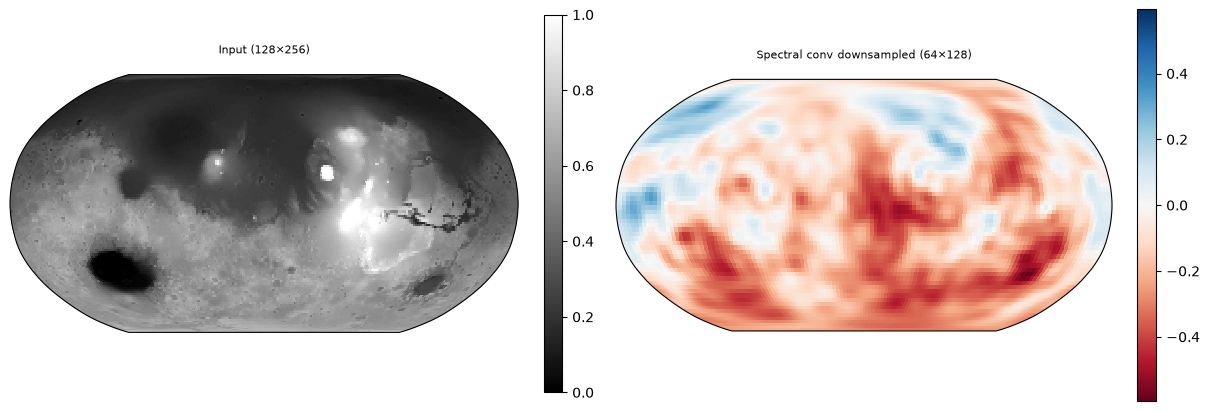

In [8]:
fig = plt.figure(figsize=(12, 4), layout="constrained")
subfigs = fig.subfigures(1, 2)

plot_sphere(signal[0, 0].detach(), fig=subfigs[0], cmap="gray",
            title="Input (128×256)", colorbar=True)

vmax = y_down[0, 0].abs().max().item()
plot_sphere(y_down[0, 0].detach(), fig=subfigs[1], cmap="RdBu",
            title="Spectral conv downsampled (64×128)", colorbar=True,
            vmin=-vmax, vmax=vmax)

plt.show()

## Summary

- **Spectral convolution** implements convolution on $S^2$ by pointwise
  multiplication in the spherical harmonic domain (SHT $\to$ spectral
  contraction $\to$ inverse SHT).
- The spectral weights depend only on degree $l$, making the kernel
  **isotropic** with a **global receptive field**.
- An optional **spectral bias** couples the spatial mean of each channel
  into all spectral modes.
- **Grouped convolution** reduces parameters by partitioning channels.
- The layer is **resolution-agnostic**: the same weights can be evaluated
  on different grids, and mismatched input/output shapes naturally
  up- or downsample.

For the full parameter documentation, see
{class}`~torch_harmonics.SpectralConvS2`.